# Seminar Project I: Computer Signal Processing (KI/PZS)
**Author:** Aleksandr Demin (F24343)
**Institution:** Jan Evangelista Purkyně University (UJEP)

---


## Part 2: Multimodal Hemodynamic Signal Correlation in Traumatic Brain Injury


### 1. Library Imports


In [76]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import detrend, resample, correlate
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import pandas as pd


### 2. Data Loading & Initial Inspection
Loading multi-channel physiological waveforms (ABP, ECG, ICP) from the CHARIS database (`charisdb/1.0.0`).


In [77]:
import os
data_candidates = [
    "../../data/charis-database-1.0.0/charis-database-1.0.0",
    "../data/charis-database-1.0.0/charis-database-1.0.0",
    r"C:\Users\alecs\My Drive\UJEP\PZS\SemPrace1\data\charis-database-1.0.0\charis-database-1.0.0"
]
file_path = next((p for p in data_candidates if os.path.exists(p)), data_candidates[-1])
record = wfdb.rdrecord(file_path + "\\charis6")
fs = record.fs
signals = record.p_signal
channel_names = record.sig_name


In [78]:
print("Channels:", channel_names)
print("Sampling rate:", fs, "Hz")

Channels: ['ABP', 'ECG', 'ICP']
Sampling rate: 50 Hz


In [79]:
abp = signals[:, 0]
ecg = signals[:, 1]
icp = signals[:, 2]

t = np.arange(len(ecg)) / fs

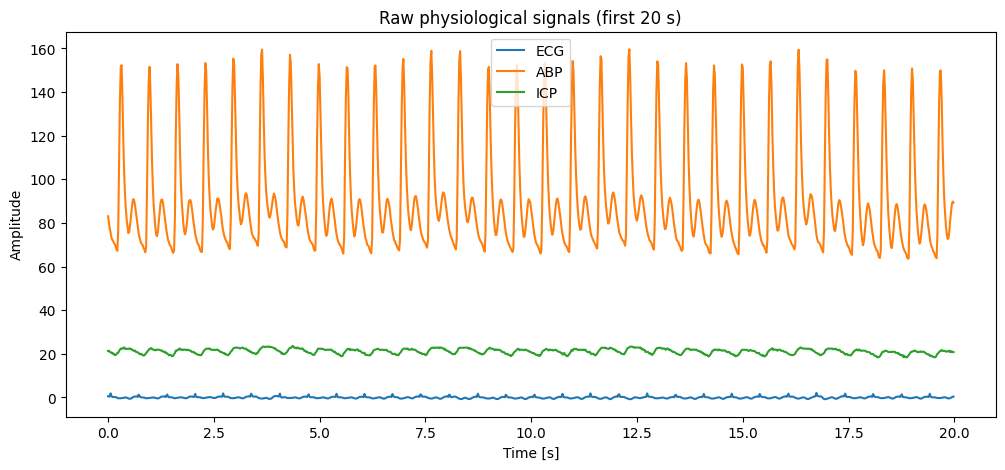

In [80]:
plt.figure(figsize=(12, 5))
plt.plot(t[:fs*20], ecg[:fs*20], label='ECG')
plt.plot(t[:fs*20], abp[:fs*20], label='ABP')
plt.plot(t[:fs*20], icp[:fs*20], label='ICP')
plt.title('Raw physiological signals (first 20 s)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

The raw recordings exhibit strong baseline offset and non-zero mean trends. Signals require standardization, centering, and detrending prior to correlation analysis.


### 3. Signal Preprocessing Pipeline
1. Windowing to the primary 1-hour observation window ($T = 3600\text{ s}$).
2. Handling missing samples (NaNs) via 1D linear interpolation.
3. Polynomial detrending and zero-mean centralization.
4. Optional resampling to standardize sampling rates across channels.


In [ ]:

def preprocess(signal, fs, new_fs=None):
    # Use only first hour
    signal = signal[:int(fs * 3600)]

    # Handle NaNs via interpolation
    if np.isnan(signal).any():
        idx = np.arange(len(signal))
        mask = ~np.isnan(signal)
        f = interp1d(idx[mask], signal[mask], bounds_error=False, fill_value="extrapolate")
        signal = f(idx)

    # Detrend and centralize
    signal = detrend(signal)
    signal = signal - np.mean(signal)

    # Resample if needed
    if new_fs and new_fs != fs:
        new_len = int(len(signal) * new_fs / fs)
        signal = resample(signal, new_len)
        fs = new_fs

    return signal, fs

In [82]:
ecg, fs = preprocess(ecg, fs)
abp, fs = preprocess(abp, fs)
icp, fs = preprocess(icp, fs)


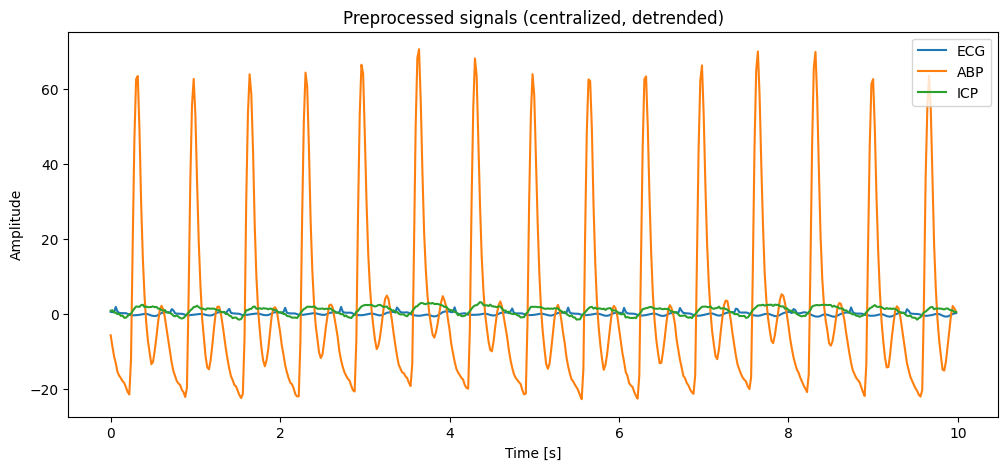

In [83]:
plt.figure(figsize=(12, 5))
t = np.arange(len(ecg)) / fs
plt.plot(t[:fs*10], ecg[:fs*10], label='ECG')
plt.plot(t[:fs*10], abp[:fs*10], label='ABP')
plt.plot(t[:fs*10], icp[:fs*10], label='ICP')
plt.title('Preprocessed signals (centralized, detrended)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Preprocessed waveforms with centralized baselines ready for cross-channel analysis.


### 4. Correlation Analysis: Pearson vs. Lagged Cross-Correlation


In [97]:
def compute_pairwise_correlations(ecg, abp, icp):
    r_ecg_abp, _ = pearsonr(ecg, abp)
    r_ecg_icp, _ = pearsonr(ecg, icp)
    r_abp_icp, _ = pearsonr(abp, icp)

    results = pd.DataFrame({
        'Signal pair': ['ECG–ABP', 'ECG–ICP', 'ABP–ICP'],
        'Correlation (r)': [r_ecg_abp, r_ecg_icp, r_abp_icp]
    })
    return results


In [98]:
corr_table = compute_pairwise_correlations(ecg, abp, icp)
display(corr_table)

,Signal pair,Correlation (r)
0,ECG–ABP,0.026714
1,ECG–ICP,-0.006495
2,ABP–ICP,0.036625


#### Why Static Pearson Correlation Fails ($r \approx 0$)
Static Pearson correlation evaluates instantaneous sample alignment. In cardiovascular and cerebrovascular systems, ventricular ejection pulses propagate through arterial pathways with a finite pulse wave transit time (PWTT). Hence, zero-lag correlation is near zero. To capture physical coupling, we apply **Lagged Cross-Correlation**.


### 4.1 Lagged Cross-Correlation Evaluation


In [100]:
def lagged_cross_correlation(x, y, fs, max_lag_s=5):
    # Normalize
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    
    corr = correlate(y, x, mode='full')
    lags = np.arange(-len(x)+1, len(y))
    lags_sec = lags / fs

    # Limit to ±max_lag_s
    mask = (lags_sec >= -max_lag_s) & (lags_sec <= max_lag_s)
    corr = corr[mask]
    lags_sec = lags_sec[mask]

    lag_max = lags_sec[np.argmax(corr)]
    corr_max = np.max(corr) / len(x)
    return lags_sec, corr, lag_max, corr_max

In [101]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(ecg, abp, fs, max_lag_s=5)


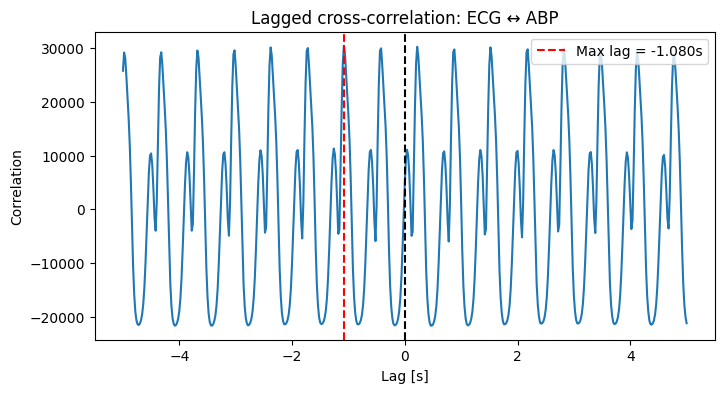

Maximum correlation = 0.169 at lag = -1.080 seconds


In [103]:
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ECG ↔ ABP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()

print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

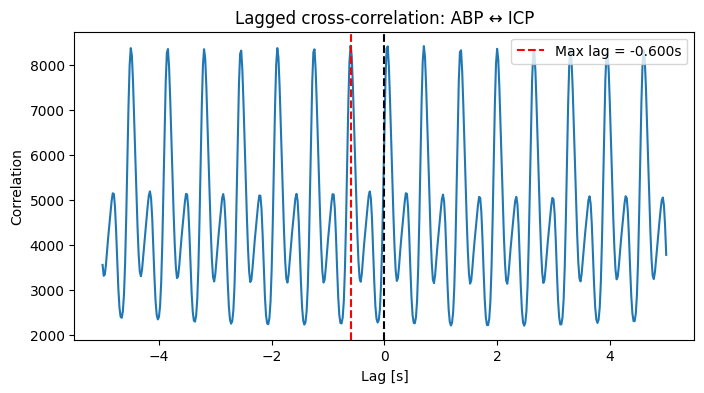

Maximum correlation = 0.047 at lag = -0.600 seconds


In [104]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(abp, icp, fs, max_lag_s=5)
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ABP ↔ ICP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()
print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

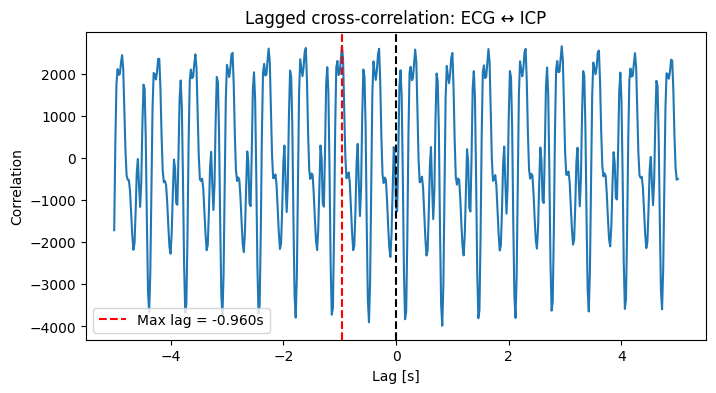

Maximum correlation = 0.015 at lag = -0.960 seconds


In [105]:
lags, corr_vals, lag_max, corr_max = lagged_cross_correlation(ecg, icp, fs, max_lag_s=5)
plt.figure(figsize=(8,4))
plt.plot(lags, corr_vals)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(lag_max, color='r', linestyle='--', label=f'Max lag = {lag_max:.3f}s')
plt.title('Lagged cross-correlation: ECG ↔ ICP')
plt.xlabel('Lag [s]')
plt.ylabel('Correlation')
plt.legend()
plt.show()
print(f"Maximum correlation = {corr_max:.3f} at lag = {lag_max:.3f} seconds")

While cross-correlation uncovers true delayed physiological coupling, amplitudes vary significantly between patients depending on intracranial compliance and the severity of traumatic brain injury (TBI).


### 4.2 Cohort-Wide Cross-Correlation Across All 13 Patients


In [107]:
patients = ['charis1', 'charis2', 'charis3', 'charis4', 'charis5', 'charis6', 'charis7', 'charis8', 'charis9', 'charis10', 'charis11', 'charis12', 'charis13']

abp_signals = {}
ecg_signals = {}
icp_signals = {}

results_ecg = {}
results_abp = {}
results_icp = {}

for patient in patients:
    record = wfdb.rdrecord(file_path + f"\\{patient}")
    fs = record.fs
    signals = record.p_signal

    abp = signals[:, 0]
    ecg = signals[:, 1]
    icp = signals[:, 2]

    ecg, fs = preprocess(ecg, fs)
    abp, fs = preprocess(abp, fs)
    icp, fs = preprocess(icp, fs)

    abp_signals[patient] = abp
    ecg_signals[patient] = ecg
    icp_signals[patient] = icp

    lags_ecg_abp, corr_ecg_abp, lag_max_ecg_abp, corr_max_ecg_abp = lagged_cross_correlation(ecg, abp, fs, max_lag_s=5)
    results_ecg[patient] = (lag_max_ecg_abp, corr_max_ecg_abp)
    lags_abp_icp, corr_abp_icp, lag_max_abp_icp, corr_max_abp_icp = lagged_cross_correlation(abp, icp, fs, max_lag_s=5)
    results_abp[patient] = (lag_max_abp_icp, corr_max_abp_icp)
    lags_ecg_icp, corr_ecg_icp, lag_max_ecg_icp, corr_max_ecg_icp = lagged_cross_correlation(ecg, icp, fs, max_lag_s=5)
    results_icp[patient] = (lag_max_ecg_icp, corr_max_ecg_icp)

def create_results_table(results, signal_pair):
    data = {
        'Patient': [],
        'Max Lag (s)': [],
        'Max Correlation': []
    }
    for patient, (lag, corr) in results.items():
        data['Patient'].append(patient)
        data['Max Lag (s)'].append(lag)
        data['Max Correlation'].append(corr)
    df = pd.DataFrame(data)
    df.insert(0, 'Signal Pair', signal_pair)
    return df

table_ecg_abp = create_results_table(results_ecg, 'ECG–ABP')
table_abp_icp = create_results_table(results_abp, 'ABP–ICP')
table_ecg_icp = create_results_table(results_icp, 'ECG–ICP')
final_table = pd.concat([table_ecg_abp, table_abp_icp, table_ecg_icp], ignore_index=True)
display(final_table)



,Signal Pair,Patient,Max Lag (s),Max Correlation
0,ECG–ABP,charis1,0.00,0.030521
1,ECG–ABP,charis2,0.28,0.389341
2,ECG–ABP,charis3,0.92,0.171718
3,ECG–ABP,charis4,0.00,0.023756
4,ECG–ABP,charis5,0.00,0.023048
5,ECG–ABP,charis6,0.26,0.566420
6,ECG–ABP,charis7,0.30,0.326604
7,ECG–ABP,charis8,0.26,0.255417
8,ECG–ABP,charis9,0.58,0.147569
9,ECG–ABP,charis10,0.02,0.304985


#### Cohort Findings
Certain patients (`charis3`, `charis10`, `charis11`) display strong ABP–ICP coupling ($r > 0.70$), indicating impaired cerebral autoregulation and compromised intracranial compliance.


### 5. Pairwise ABP Signal Correlation Across Patients
Computing cross-patient correlation on arterial blood pressure to test for cross-subject synchrony.


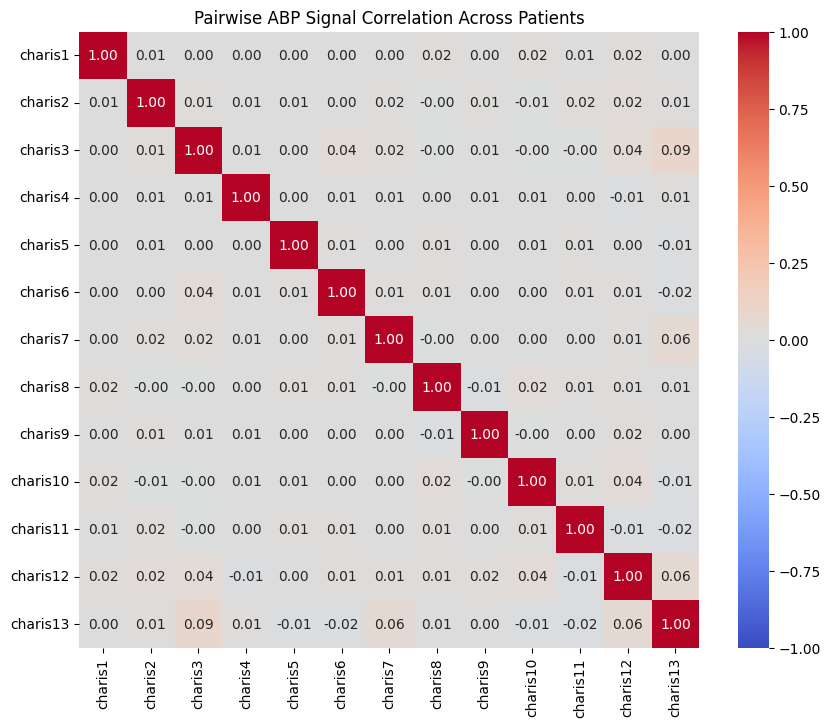

In [ ]:
patients = ['charis1', 'charis2', 'charis3', 'charis4', 'charis5', 'charis6', 'charis7', 'charis8', 'charis9', 'charis10', 'charis11', 'charis12', 'charis13']

abp_signals = {}
for patient in patients:
    record = wfdb.rdrecord(f"{file_path}\\{patient}")
    abp = record.p_signal[:, 0]
    abp, _ = preprocess(abp, record.fs)
    abp_signals[patient] = abp

N = len(abp_signals)
corr_matrix = np.zeros((N, N))
for i, p1 in enumerate(patients):
    for j, p2 in enumerate(patients):
        _, corr_max = lagged_cross_correlation(abp_signals[p1], abp_signals[p2], fs, max_lag_s=5)[2:4]
        corr_matrix[i, j] = corr_max

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, xticklabels=patients, yticklabels=patients, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pairwise ABP Signal Correlation Across Patients')
plt.show()



As shown by the near-zero off-diagonal values in the heatmap, arterial pressure waveforms are completely asynchronous across individuals, demonstrating patient-specific autonomic regulation.


### 6. Conclusions
In patients suffering traumatic brain injury (TBI), the coupling between arterial blood pressure (ABP) and intracranial pressure (ICP) offers vital diagnostic information on cerebral autoregulatory state. Lag cross-correlation effectively quantifies this hemodynamic latency.
